### Simple Multi-Agent Architecture

In [ ]:
import os
from dotenv import load_dotenv
from typing import TypedDict, Annotated, List, Literal, Dict
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.graph.message import add_messages
from langchain.agents import create_agent
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command, interrupt
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
import random
from datetime import datetime

In [12]:
load_dotenv()

groq_api_key = os.getenv('GROQ_API_KEY')
tavily_api_key = os.getenv('TAVILY_API_KEY')

In [13]:
llm = ChatGroq(model="openai/gpt-oss-20b", api_key=groq_api_key, max_tokens=7000)

In [ ]:
# MessageState is same as defining your own State class (this pre-built abstracts way those boilerplates)
class AgentState(MessagesState):


In [15]:
@tool
def search_web(query: str) -> str:
    """Search the web for information"""
    search = TavilySearch(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content: str) -> str:
    """ Write a Summary of the provided content."""
    summary = f"Summary of findings: \n\n{content[:500]}"
    return summary

In [ ]:
# Define agent functions (simpler approach)
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""
    
    messages = state["messages"]
    
    # Add system message for context
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")
    
    # Call LLM with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)
    
    # Return the response and route to writer
    return {"messages": [response]}

In [ ]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""
    
    messages = state["messages"]
    
    # Add system message
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")
    
    # Simple completion without tools
    response = llm.invoke([system_msg] + messages)
    
    return {"messages": [response]}

In [18]:
# Tool executor node (example how the tool node basically works - not used in the usecase)
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        # Create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response
    
    # No tools to execute
    return state

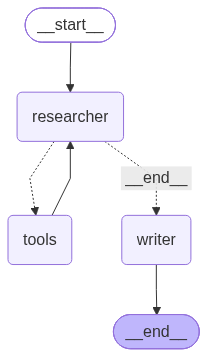

In [19]:
# Build graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("tools", ToolNode([search_web, write_summary]))
workflow.add_node("writer", writer_agent)

# Define flow
workflow.add_edge(START, "researcher")
workflow.add_conditional_edges(
    "researcher",
    tools_condition,
    {"tools": "tools", "__end__": "writer"}
)
workflow.add_edge("tools", "researcher")  # loop back so researcher sees the tool result
workflow.add_edge("writer", END)
final_workflow = workflow.compile()

final_workflow

In [20]:
response=final_workflow.invoke({"messages":"Reasearch about the usecase of agentic ai in business"})

In [21]:
response["messages"][-1].content

'**Agentic AI in Business – Executive Summary**\n\n1. **What is Agentic AI?**  \n   - Autonomous AI systems that can independently decide, plan, and execute multi‑step tasks across enterprise environments.  \n   - Goes beyond “follow‑instruction” chatbots to true “goal‑oriented” behavior.\n\n2. **Core Capabilities**  \n   - **Autonomy & Goal‑Directedness** – agents pursue defined business objectives without constant human input.  \n   - **Multi‑step Reasoning** – coordinate actions across multiple systems and stakeholders.  \n   - **Learning & Adaptation** – refine policies from real‑world outcomes.\n\n3. **High‑Impact Business Use Cases**  \n   | Domain | Typical Agentic‑AI Activity | Business Benefit | Representative Example |\n   |--------|---------------------------|------------------|------------------------|\n   | Customer Support | Auto‑routing & resolution of tickets | 30‑50\u202f% faster resolution | Zendesk + GPT‑4 agent |\n   | Supply‑Chain | End‑to‑end order fulfillment & r

In [34]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

Reasearch about the usecase of agentic ai in business
================================== Ai Message ==================================
Tool Calls:
  search_web (fc_4dfcb6aa-2a2f-4549-b5f9-17c5d0c7b9b1)
 Call ID: fc_4dfcb6aa-2a2f-4549-b5f9-17c5d0c7b9b1
  Args:
    query: agentic AI use cases in business
================================= Tool Message =================================
Name: search_web

{'query': 'agentic AI use cases in business', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://kodexolabs.com/agentic-ai-use-cases', 'title': '7 Promising Agentic AI Use Cases with Real-World Business Examples for 2025 | Kodexo Labs', 'content': '# 7 Promising Agentic AI Use Cases with Real-World Business Examples for 2025. Agentic AI Use Cases with Real-World Business Examples. Agentic AI use cases are revolutionizing how enterprises operate in 2025, with autonomous syst